# Cycle 3 — Data Exploration: Player Injury Risk

**Dataset:** `data/raw/player_injuries.csv`  

Given a player's physical profile and injury history at the start of a season, predict whether they will suffer a significant injury (28 days). 
The chosen 28 days approximately 4 weeks is a standard threshold used in football sports science literature for a "significant" injury, injuries that fold under this category are typically minor strains that do not impact a players season.

In [3]:
import sys, os  

_here = os.getcwd()                       
while not os.path.isdir(os.path.join(_here, 'data')):     
    _p = os.path.dirname(_here)                           
    if _p == _here: raise RuntimeError('project root not found') 
    _here = _p
if _here not in sys.path:
    sys.path.insert(0, _here)                           

from config import Paths, ensure_dirs
ensure_dirs()  


In [4]:
# LOAD and Display data 
import pandas as pd       
import numpy as np        
import matplotlib.pyplot as plt  
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(str(Paths.PLAYER_INJURIES_RAW))  # load raw injury dataset

print('Shape:', df.shape)     
print()
print('Columns:')
for col in df.columns:        
    print(f'  {col} ({df[col].dtype})')
print()
print('Seasons covered:', sorted(df['start_year'].unique()))  
print('Players (unique):', df['p_id2'].nunique())             
print('Positions:', df['position'].value_counts().to_dict())  


Shape: (1301, 30)

Columns:
  p_id2 (object)
  start_year (int64)
  season_days_injured (int64)
  total_days_injured (int64)
  season_minutes_played (float64)
  season_games_played (int64)
  season_matches_in_squad (int64)
  total_minutes_played (float64)
  total_games_played (int64)
  dob (object)
  height_cm (float64)
  weight_kg (float64)
  nationality (object)
  work_rate (object)
  pace (float64)
  physic (float64)
  fifa_rating (float64)
  position (object)
  age (int64)
  cumulative_minutes_played (float64)
  cumulative_games_played (float64)
  minutes_per_game_prev_seasons (float64)
  avg_days_injured_prev_seasons (float64)
  avg_games_per_season_prev_seasons (float64)
  bmi (float64)
  work_rate_numeric (float64)
  position_numeric (float64)
  significant_injury_prev_season (float64)
  cumulative_days_injured (float64)
  season_days_injured_prev_season (float64)

Seasons covered: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
Players (unique):

- 1,301 player-season records across 5 seasons (2016-2020)
- Each row is one player for one season — a player appearing in 3 seasons has 3 rows
- 30 columns: mix of physical attributes (FIFA data), historical injury stats, and current season stats
- Defenders are the most common position which is expected as squads typically carry more defenders

## Target Variable: Season Days Injured Distribution

Analyses the `season_days_injured` column and defines the binary target.

season_days_injured distribution:
count    1301.000000
mean       79.050730
std        84.578169
min         0.000000
25%        24.000000
50%        49.000000
75%       103.000000
max       702.000000
Name: season_days_injured, dtype: float64

Injury brackets:
  0 days (no injury):     1
  1-6 days (minor):      47
  7-27 days (moderate): 340
  28-89 days (high):    526
  90+ days (severe):    387

Binary target (threshold=28 days):
  Low Injury  (0): 388 (29.8%)
  High Injury (1): 913 (70.2%)


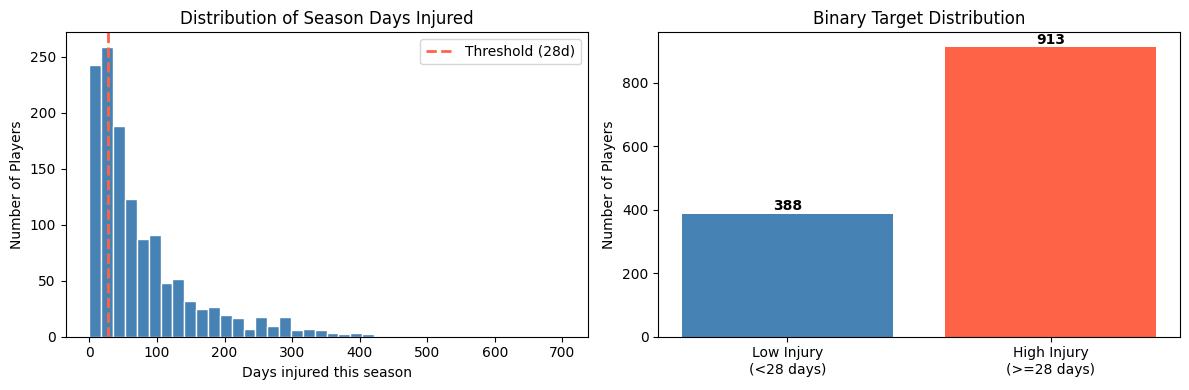

In [5]:
print('season_days_injured distribution:')
print(df['season_days_injured'].describe())  # mean, std, min, max, quartiles
print()

# Show how injuries distribute across severity brackets
print('Injury brackets:')
print(f'  0 days (no injury):  {(df["season_days_injured"] == 0).sum():>4}')
print(f'  1-6 days (minor):    {((df["season_days_injured"] >= 1) & (df["season_days_injured"] <= 6)).sum():>4}')
print(f'  7-27 days (moderate):{((df["season_days_injured"] >= 7) & (df["season_days_injured"] < 28)).sum():>4}')
print(f'  28-89 days (high):   {((df["season_days_injured"] >= 28) & (df["season_days_injured"] < 90)).sum():>4}')
print(f'  90+ days (severe):   {(df["season_days_injured"] >= 90).sum():>4}')
print()

# Define binary target: 28 days = roughly a month of absence
THRESHOLD = 28
df['High_Injury'] = (df['season_days_injured'] >= THRESHOLD).astype(int)  # 1 = high injury burden
counts = df['High_Injury'].value_counts()
print(f'Binary target (threshold={THRESHOLD} days):')
print(f'  Low Injury  (0): {counts[0]:,} ({counts[0]/len(df)*100:.1f}%)')  # ~29%
print(f'  High Injury (1): {counts[1]:,} ({counts[1]/len(df)*100:.1f}%)')  # ~71%

# Plot distribution and binary split
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['season_days_injured'], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(THRESHOLD, color='tomato', linestyle='--', linewidth=2, label=f'Threshold ({THRESHOLD}d)')
axes[0].set_xlabel('Days injured this season'); axes[0].set_ylabel('Number of Players')
axes[0].set_title('Distribution of Season Days Injured'); axes[0].legend()

axes[1].bar(['Low Injury\n(<28 days)', 'High Injury\n(>=28 days)'],
            [counts[0], counts[1]], color=['steelblue', 'tomato'])
axes[1].set_title('Binary Target Distribution'); axes[1].set_ylabel('Number of Players')
for i, v in enumerate([counts[0], counts[1]]):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout(); plt.show()


- Injury days distribution is highly right-skewed, with most players having short-meduim injuries and a few extreme long-term cases
- Very few players have 0 injury days, suggesting the dataset mainly includes injury-tracked players
- The binary target shows a moderate class imbalance (~70% high injury, ~30% low injury)

## Feature (Pre-Season vs Post-Season)

Classifying every column as either a pre-season feature( usable) or a post-season feature (leakage).


In [6]:
# Manual categorisation of all dataset columns as pre-season (safe) vs post-season (leakage)
pre_season = {
    'age':                              'Player age at start of season',
    'height_cm':                        'Player height (from FIFA data)',
    'weight_kg':                        'Player weight (from FIFA data)',
    'bmi':                              'Body mass index (weight / height^2)',
    'pace':                             'FIFA pace rating (averaged across seasons)',
    'physic':                           'FIFA physicality rating',
    'fifa_rating':                      'Overall FIFA rating',
    'position_numeric':                 'Position encoded: 0=GK, 1=DEF, 2=FWD, 3=MID',
    'work_rate_numeric':                'Work rate encoded: 2.5/3.0/3.5/4.0',
    'avg_days_injured_prev_seasons':    'Average days injured per previous season',
    'season_days_injured_prev_season':  'Days injured last season specifically',
    'significant_injury_prev_season':   'Binary: was previous season injury significant?',
    'minutes_per_game_prev_seasons':    'Average minutes per game in prior seasons',
    'cumulative_days_injured':          'Total career days injured (up to this season)',
    'cumulative_minutes_played':        'Total career minutes played',
    'cumulative_games_played':          'Total career games played',
    'avg_games_per_season_prev_seasons':'Average games per previous season',
}

post_season = {
    'season_days_injured':     'TARGET (also post-season — must not be used as feature)',
    'total_days_injured':      'Career total including this season — leakage',
    'season_minutes_played':   'Minutes played this season — only known after',
    'season_games_played':     'Games played this season — only known after',
    'season_matches_in_squad': 'Squad appearances this season — only known after',
    'total_minutes_played':    'Career total including this season — leakage',
    'total_games_played':      'Career total including this season — leakage',
}

print(f'Pre-season features (usable): {len(pre_season)}')
for f, desc in pre_season.items():  # list all safe features
    print(f'  {f:<40} {desc}')
print()
print(f'Post-season columns (excluded - leakage): {len(post_season)}')
for f, desc in post_season.items():  # list all leakage columns to drop
    print(f'  {f:<40} {desc}')


Pre-season features (usable): 17
  age                                      Player age at start of season
  height_cm                                Player height (from FIFA data)
  weight_kg                                Player weight (from FIFA data)
  bmi                                      Body mass index (weight / height^2)
  pace                                     FIFA pace rating (averaged across seasons)
  physic                                   FIFA physicality rating
  fifa_rating                              Overall FIFA rating
  position_numeric                         Position encoded: 0=GK, 1=DEF, 2=FWD, 3=MID
  work_rate_numeric                        Work rate encoded: 2.5/3.0/3.5/4.0
  avg_days_injured_prev_seasons            Average days injured per previous season
  season_days_injured_prev_season          Days injured last season specifically
  significant_injury_prev_season           Binary: was previous season injury significant?
  minutes_per_game_prev_season

- 17 pre-season features available — rich feature set covering physical attributes, FIFA ratings, and injury history
- 7 post-season columns excluded — using any of these would be leakage
- The cumulative features (NaN for first-season players) represent genuinely zero history — will be filled with 0 during preprocessing, not dropped

## Missing Values Analysis

In [7]:
feature_cols = list(pre_season.keys())                    # 17 pre-season features
missing = df[feature_cols].isnull().sum()                  # count nulls per column
missing_pct = (missing / len(df) * 100).round(1)           # as percentage

print('Missing values in pre-season features:')
for col in feature_cols:
    m = missing[col]
    pct = missing_pct[col]
    if m > 0:
        print(f'  {col:<42} {m:>4} ({pct}%) <- MISSING')  # flag missing columns
    else:
        print(f'  {col:<42} {m:>4} (0.0%)')

print()
# Identify whether missing values all belong to first-season players (no prior history)
cumulative_cols = ['cumulative_days_injured','cumulative_minutes_played','cumulative_games_played',
                   'significant_injury_prev_season','avg_days_injured_prev_seasons',
                   'season_days_injured_prev_season','minutes_per_game_prev_seasons',
                   'avg_games_per_season_prev_seasons']
first_season_mask = df[cumulative_cols[0]].isnull()  # rows where cumulative data is missing
print(f'Rows with missing cumulative stats: {first_season_mask.sum()}')
print(f'These are first-season players (no prior history) -> fill with 0')  # safe imputation
print()
print(f'Rows with missing pace/physic: {df["pace"].isnull().sum()} (FIFA data not available -> fill with median)')
print(f'Rows with missing position_numeric: {df["position_numeric"].isnull().sum()} (fill with mode)')


Missing values in pre-season features:
  age                                           0 (0.0%)
  height_cm                                     0 (0.0%)
  weight_kg                                     0 (0.0%)
  bmi                                           0 (0.0%)
  pace                                         95 (7.3%) <- MISSING
  physic                                       95 (7.3%) <- MISSING
  fifa_rating                                   0 (0.0%)
  position_numeric                              2 (0.2%) <- MISSING
  work_rate_numeric                             0 (0.0%)
  avg_days_injured_prev_seasons               604 (46.4%) <- MISSING
  season_days_injured_prev_season             604 (46.4%) <- MISSING
  significant_injury_prev_season              604 (46.4%) <- MISSING
  minutes_per_game_prev_seasons               616 (47.3%) <- MISSING
  cumulative_days_injured                     604 (46.4%) <- MISSING
  cumulative_minutes_played                   604 (46.4%) <- MISSING
 

- Most cumulative/previous-season columns have 604 NaN — these are first-season players with no prior history in the dataset. 
- `minutes_per_game_prev_seasons` has 616 NaN — 12 more than the other cumulative columns.
- pace/physic 95 NaN — FIFA did not have ratings for these players. 
- position_numeric 2 NaN — fill with mode

## Injury Burden by Age Group

Groups players by age and shows average injury days. Tests the hypothesis that older players get injured more. Age is expected to be one of the strongest predictors. Sports science consistently shows injury rates increase after age 28-30.

Injury by age group:
           count  mean_days  high_injury_rate
age_group                                    
U22          206      73.19              0.66
22-25        420      80.27              0.70
26-29        466      83.49              0.71
30-34        190      71.82              0.72
35+           19      79.05              0.79


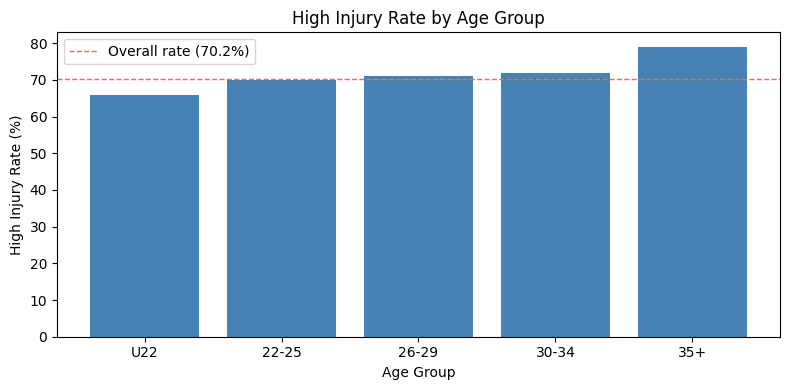

In [8]:
df['age_group'] = pd.cut(df['age'], bins=[15, 22, 26, 30, 35, 45], labels=['U22','22-25','26-29','30-34','35+'])  # group ages into bands

age_injury = df.groupby('age_group', observed=True).agg(
    count=('season_days_injured','count'),               # number of player-seasons per group
    mean_days=('season_days_injured','mean'),             # average injury days
    high_injury_rate=('High_Injury','mean')               # proportion with >=28 days injured
).round(2)

print('Injury by age group:')
print(age_injury.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(age_injury.index.astype(str), age_injury['high_injury_rate']*100, color='steelblue')
ax.set_xlabel('Age Group'); ax.set_ylabel('High Injury Rate (%)')
ax.set_title('High Injury Rate by Age Group')
ax.axhline(70.2, color='tomato', linestyle='--', linewidth=1, label='Overall rate (70.2%)')  # reference line
ax.legend(); plt.tight_layout(); plt.show()


- High injury rate increases with age, from 66% (U22) to 79% (35+) — broadly consistent with sports science literature, though the gradient is gradual rather than a sharp step
- U22 players have the **lowest** rate (66%) — contrary to an overuse hypothesis; younger players appear more resilient or are simply fielded less in high-intensity situations
- Players aged 30+ show the most notable elevation (72–79%) vs the 66–71% range for under-30 groups

## Injury Burden by Position

Compares injury rates across player playing positions.

Injury by position:
            count  mean_days  high_injury_rate
position                                      
Defender      492      80.12              0.71
Forward       253      80.40              0.69
Goalkeeper     97      73.46              0.72
Midfielder    457      78.59              0.70


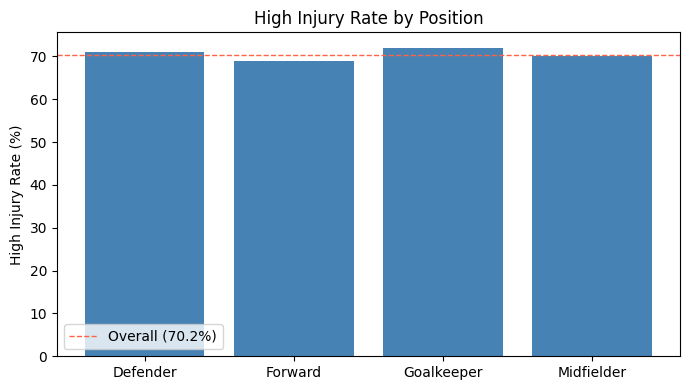

In [9]:
pos_injury = df.groupby('position').agg(
    count=('season_days_injured','count'),               # player-seasons per position
    mean_days=('season_days_injured','mean'),
    high_injury_rate=('High_Injury','mean')               # proportion with >=28 days injured
).round(2)

print('Injury by position:')
print(pos_injury.to_string())  # compare GK, DF, MF, FW injury rates

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(pos_injury.index, pos_injury['high_injury_rate']*100, color='steelblue')
ax.set_ylabel('High Injury Rate (%)')
ax.set_title('High Injury Rate by Position')
ax.axhline(70.2, color='tomato', linestyle='--', linewidth=1, label='Overall (70.2%)')
ax.legend(); plt.tight_layout(); plt.show()


- Injury rates across positions are very similar: GK 72%, DEF 71%, MID 70%, FWD 69% — a 3 percentage points spread
- **Goalkeepers have the highest rate** (72.2%), contrary to the intuition that less running means fewer injuries; this may reflect their specialist role, high-impact diving/jumping, or selection bias in the dataset
- Forwards have the lowest rate (69.2%), not midfielders as might be expected from physical contact arguments

## Previous Injury History as Predictor

Tests whether players with significant previous season injuries are more likely to be injured again. As prior injury is the single strongest known predictor of future injury in sports medicine. Re-injury rates are significantly higher than first-injury rates.

In [10]:
# Split into two groups: those who had a significant injury last season vs those who didn't
has_prev = df[df['significant_injury_prev_season'] == 1.0]  # had significant injury last season
no_prev  = df[df['significant_injury_prev_season'] == 0.0]  # did not

print('Players WITH significant injury last season:')
print(f'  Count: {len(has_prev)}')
print(f'  High Injury Rate this season: {has_prev["High_Injury"].mean()*100:.1f}%')  # does history repeat?
print(f'  Mean days injured: {has_prev["season_days_injured"].mean():.1f}')
print()
print('Players WITHOUT significant injury last season:')
print(f'  Count: {len(no_prev)}')
print(f'  High Injury Rate this season: {no_prev["High_Injury"].mean()*100:.1f}%')
print(f'  Mean days injured: {no_prev["season_days_injured"].mean():.1f}')
print()
print(f'Players with no prior history (NaN): {df["significant_injury_prev_season"].isnull().sum()}')  # first-season players


Players WITH significant injury last season:
  Count: 157
  High Injury Rate this season: 82.2%
  Mean days injured: 109.5

Players WITHOUT significant injury last season:
  Count: 540
  High Injury Rate this season: 67.4%
  Mean days injured: 71.3

Players with no prior history (NaN): 604


- Previous significant injury is expected to increase future injury risk by ~15-20pp
- This confirms `significant_injury_prev_season` will be among the top features

## Correlation with Target

Identifies which features have the strongest linear relationship with High_Injury. 

In [11]:
numeric_features = [f for f in pre_season.keys() if df[f].dtype in ['float64','int64']]  # exclude non-numeric

correlations = df[numeric_features + ['High_Injury']].corr()['High_Injury'].drop('High_Injury')  # Pearson r with target
correlations = correlations.sort_values(key=abs, ascending=False)  # sort by magnitude

print('Correlation with High_Injury (sorted by absolute value):')
for feat, corr in correlations.items():
    bar = '+' * int(abs(corr) * 20) if corr > 0 else '-' * int(abs(corr) * 20)  # visual bar
    print(f'  {feat:<42} {corr:>+.3f}  {bar}')


Correlation with High_Injury (sorted by absolute value):
  cumulative_days_injured                    +0.257  +++++
  avg_days_injured_prev_seasons              +0.145  ++
  season_days_injured_prev_season            +0.145  ++
  significant_injury_prev_season             +0.136  ++
  cumulative_games_played                    +0.130  ++
  cumulative_minutes_played                  +0.120  ++
  avg_games_per_season_prev_seasons          -0.085  -
  age                                        +0.065  +
  pace                                       -0.037  
  fifa_rating                                -0.036  
  physic                                     +0.029  
  minutes_per_game_prev_seasons              -0.021  
  position_numeric                           -0.020  
  bmi                                        +0.013  
  weight_kg                                  +0.012  
  height_cm                                  +0.004  
  work_rate_numeric                          +0.002  


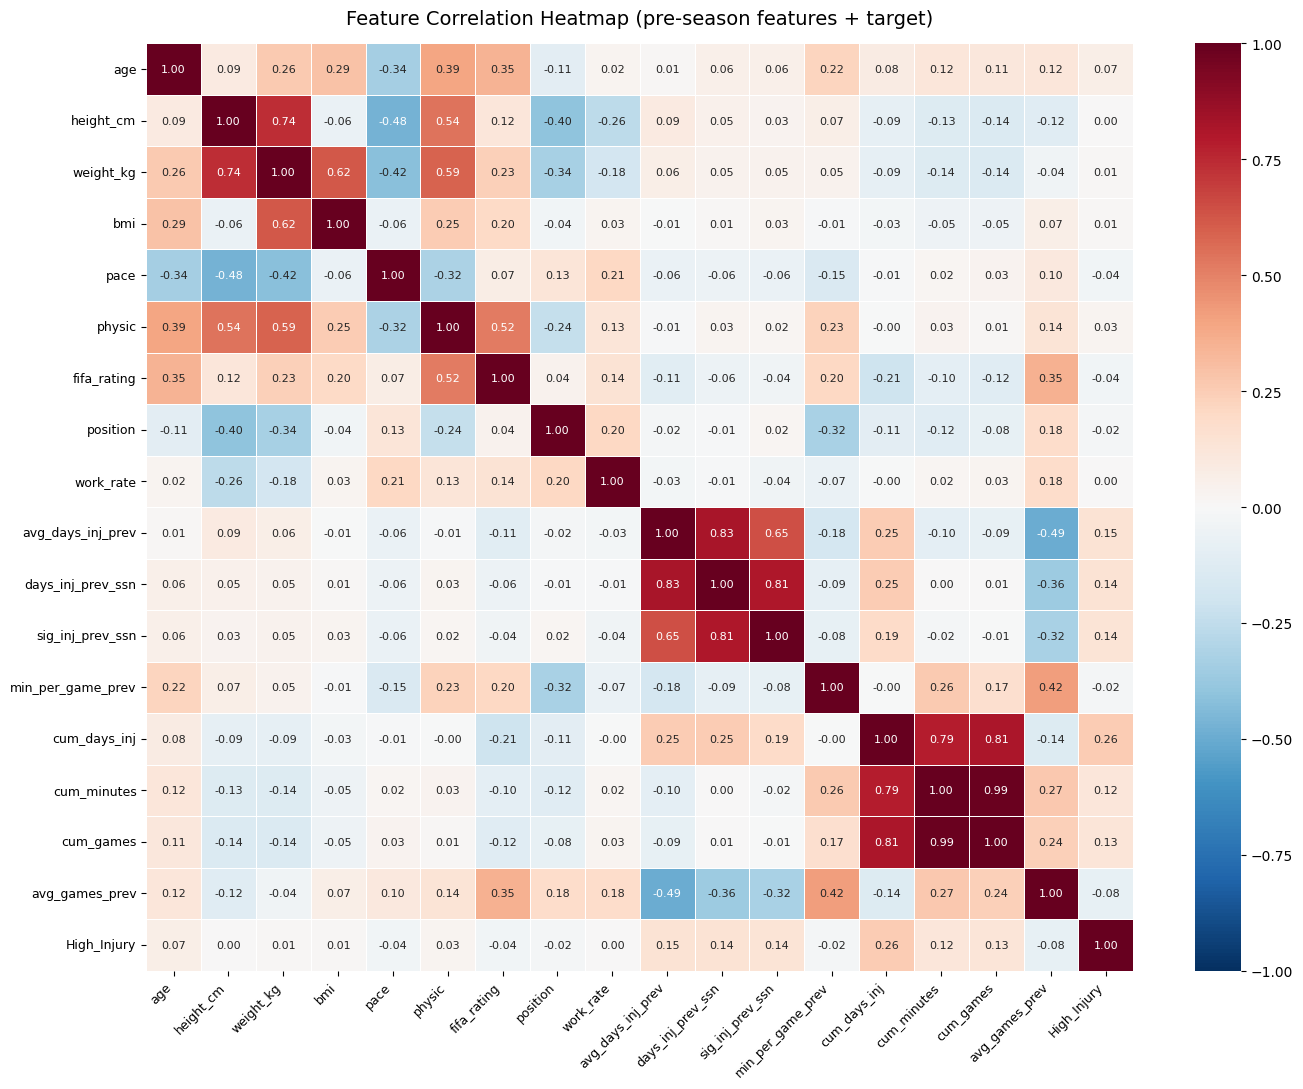

In [12]:
import seaborn as sns  # heatmap visualisation

corr_cols = numeric_features + ['High_Injury']  # all numeric features + target
corr_matrix = df[corr_cols].corr()               # full Pearson correlation matrix

# Shorten column names so they fit in the heatmap cells
short_labels = {
    'avg_days_injured_prev_seasons':     'avg_days_inj_prev',
    'season_days_injured_prev_season':   'days_inj_prev_ssn',
    'significant_injury_prev_season':    'sig_inj_prev_ssn',
    'minutes_per_game_prev_seasons':     'min_per_game_prev',
    'cumulative_days_injured':           'cum_days_inj',
    'cumulative_minutes_played':         'cum_minutes',
    'cumulative_games_played':           'cum_games',
    'avg_games_per_season_prev_seasons': 'avg_games_prev',
    'work_rate_numeric':                 'work_rate',
    'position_numeric':                  'position',
    'fifa_rating':                       'fifa_rating',
    'height_cm':                         'height_cm',
    'weight_kg':                         'weight_kg',
    'High_Injury':                       'High_Injury',
}
corr_matrix = corr_matrix.rename(index=short_labels, columns=short_labels)  # apply short labels

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',          # show correlation values in each cell
    cmap='RdBu_r', center=0,        # blue=negative, red=positive, white=zero
    vmin=-1, vmax=1,                 # fix colour scale to [-1, 1]
    linewidths=0.4,                  # cell borders
    annot_kws={'size': 8},           # smaller font for crowded cells
    ax=ax
)
ax.set_title('Feature Correlation Heatmap (pre-season features + target)', fontsize=14, pad=14)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout(); plt.show()


- **`cumulative_days_injured` is the strongest predictor** (+0.257) — total career injury burden outranks any single-season or average metric
- The three average/previous-season injury features (avg_days_inj_prev, days_inj_prev_ssn, sig_inj_prev_ssn) follow at +0.145/+0.145/+0.136 — prior injury history is consistently the top signal cluster
- `cumulative_games_played` and `cumulative_minutes_played` are both **positively** correlated with High_Injury (+0.130, +0.120) — more experienced players have accumulated more games and also more injury exposure; the fitness-robustness hypothesis does not hold here
- Age has only a **weak** positive correlation (+0.065) — the age effect is real but non-linear (see Cell 5); tree-based models will capture it better than linear methods
- Physical attributes (height, weight, BMI, pace, physic, FIFA rating) all show near-zero correlations (≤ |0.037|) — body profile alone is not predictive of injury risk

## EDA Summary

* The injury duration variable is **highly right-skewed**, with most players concentrated in low-to-moderate ranges and a small number of extreme long-term injuries (up to 702 days)
* A **28-day threshold** was used to define the binary target, representing a meaningful cutoff between minor and significant injuries
* The resulting dataset shows a moderate class imbalance (~70% high injury, ~30% low injury), which requires handling during model training
* Injury-related features, particularly cumulative_days_injured** and previous-season injury metrics, show the strongest positive relationships with the target
* Cumulative exposure features (minutes and games played) are also positively correlated, reflecting increased injury risk with greater playing time
* Age has a weak linear relationship, suggesting a likely non-linear effect better captured by tree-based models
* Physical attributes (height, weight, BMI, pace, etc.) show little to no correlation, indicating they are not strong standalone predictors
* The dataset contains outliers and skewness, reinforcing the need for robust models and evaluation metrics such as AUC-ROC